# EDA, klasteryzacja i redukcja wymiarów

Notebook ma na celu:
-  przedstawić podstawowe cechy zbioru
-  sprawdzić komletność i typ danych
-  wyświetlić rozkłady interesujących cech (alcohol, pH, quality)
-  wykryć wartości odstające
-  pokazać korelację między danymi
-  zwizualizować zbiór przy pomocy technik redukcji wymiarów PCA, LDA
-  pokazać zastosowanie uczenia nienadzorowanego (klasteryzacji k-mean)
-  zwizualizować jak działają metody resamplingu dla danych niezbalansowanych (SMOTE, RandomOverSampling, RandomUnderSampling)

In [309]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
pd.set_option('display.max_columns',None)
sns.set(style="whitegrid")
plt.style.use('default')  # reset stylu
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

palette = {
    3: "#e41a1c",  # czerwony
    4: "#377eb8",  # niebieski
    5: "#4daf4a",  # zielony
    6: "#984ea3",  # fioletowy
    7: "#EF00FF",  # różowy
    8: "#ffff33"   # żółty
}

df = pd.read_csv("../Dataset/WineQT.csv")
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [310]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [311]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [312]:
# Find duplicate rows
duplicates = df[df.duplicated()]

print(duplicates["quality"].value_counts().sort_index())
print("Suma duplikatów: ",df.duplicated().sum())

Series([], Name: count, dtype: int64)
Suma duplikatów:  0


In [313]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [314]:
df = df.drop(['Id'],axis=1)
y = df['quality']
X = df.drop(['quality'],axis=1)
categorial_features = X.select_dtypes(include=['category','str','object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64','float64']).columns.tolist()

n_samples = len(X)
n_features = len(X.T)
classes, counts = np.unique(y,return_counts=True)
imbalanced_ratio = np.max(counts)/np.min(counts)

print("n_samples: ", n_samples)
print("n_features: ", n_features)
print("categorical: ", len(categorial_features))
print("numerical: ", len(numerical_features))
print("classes: ", classes)
print("class samples: ", counts)
print("imbalanced ratio: ", imbalanced_ratio)

n_samples:  1143
n_features:  11
categorical:  0
numerical:  11
classes:  [3 4 5 6 7 8]
class samples:  [  6  33 483 462 143  16]
imbalanced ratio:  80.5


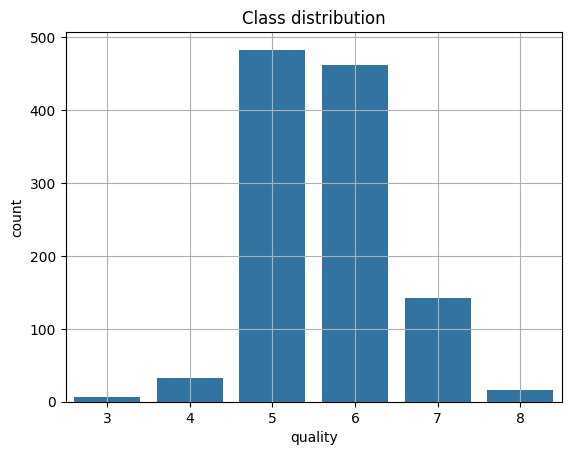

In [315]:
sns.countplot(x="quality", data=df)
plt.title("Class distribution")
plt.grid()
plt.show()

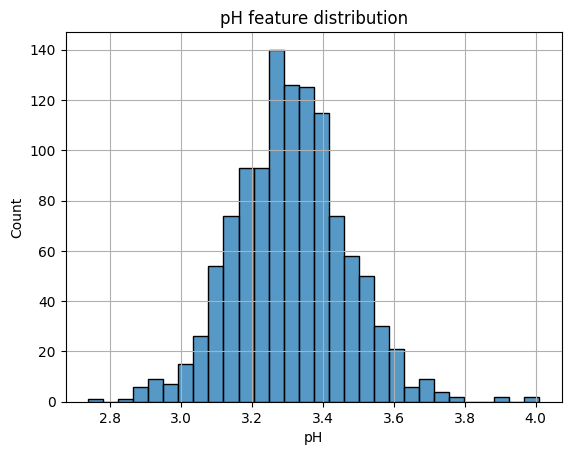

In [316]:
sns.histplot(x="pH", data=df, bins=30)
plt.title("pH feature distribution")
plt.grid()
plt.show()

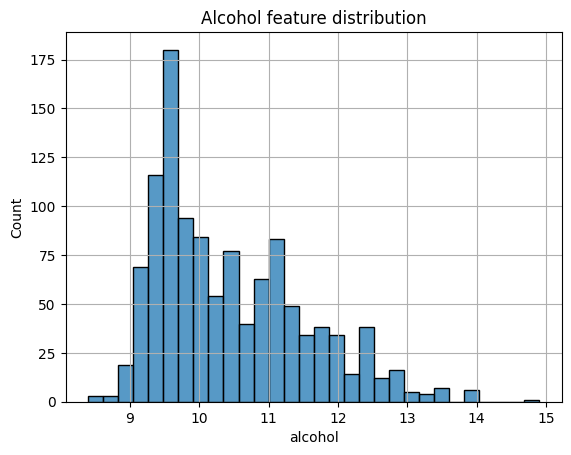

In [317]:
sns.histplot(x="alcohol", data=df, bins=30)
plt.title("Alcohol feature distribution")
plt.grid()
plt.show()

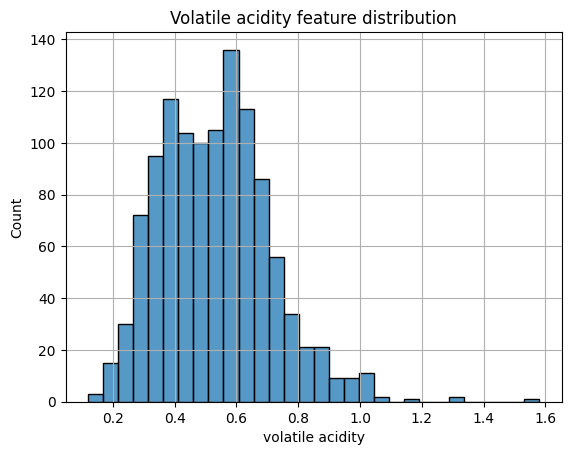

In [318]:
sns.histplot(x="volatile acidity", data=df, bins=30)
plt.title("Volatile acidity feature distribution")
plt.grid()
plt.show()

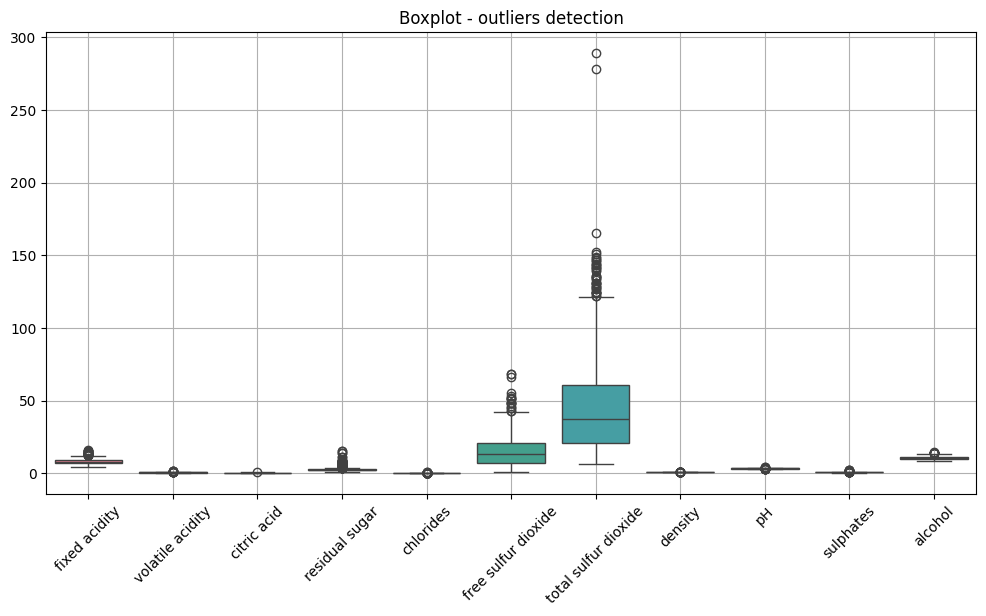

In [319]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X)
plt.xticks(rotation=45)
plt.title("Boxplot - outliers detection")
plt.grid()
plt.show()

In [320]:
results = []

for col in X.columns:

    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = (
        (X[col] < lower) |
        (X[col] > upper)
    ).sum()

    results.append({
        "feature": col,
        "outliers": n_outliers,
        "percent": round(
            100 * n_outliers / len(X),
            2
        )
    })

print(pd.DataFrame(results).sort_values("outliers", ascending=False))

                 feature  outliers  percent
3         residual sugar       110     9.62
4              chlorides        77     6.74
0          fixed acidity        44     3.85
9              sulphates        43     3.76
6   total sulfur dioxide        40     3.50
7                density        36     3.15
8                     pH        20     1.75
5    free sulfur dioxide        18     1.57
1       volatile acidity        14     1.22
10               alcohol        12     1.05
2            citric acid         1     0.09


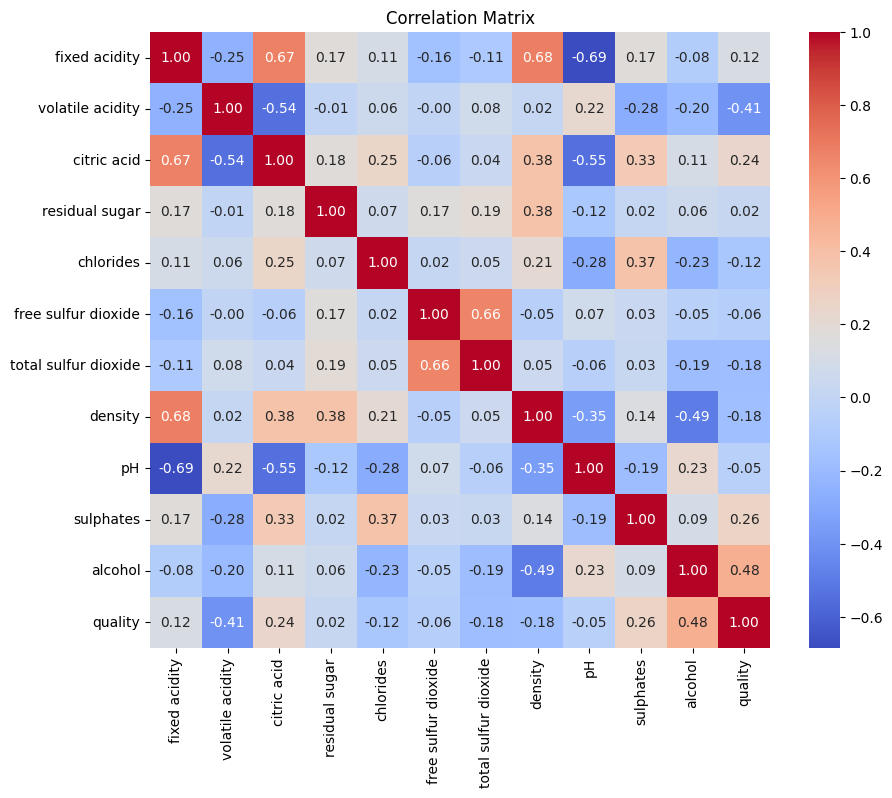

In [321]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig("../charts/Correlation_Matrix.png")
plt.show()

In [322]:
#X = X.drop(["pH"],axis=1)  # Do zbadania wpływu usunięcia cechy na podział klastrów
# skalowanie
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-0.52157961  0.93933222 -1.36502663 ...  1.27069495 -0.57365783
  -0.96338181]
 [-0.29259344  1.94181282 -1.36502663 ... -0.70892755  0.1308811
  -0.59360107]
 [-0.29259344  1.27349242 -1.16156762 ... -0.32577481 -0.04525363
  -0.59360107]
 ...
 [-1.20853813  0.38239855 -0.9581086  ...  0.88754221 -0.45623467
   0.05351522]
 [-1.38027776  0.10393172 -0.8563791  ...  1.33455374  0.60057372
   0.70063152]
 [-1.38027776  0.6330187  -0.75464959 ...  1.65384769  0.30701583
  -0.22382033]]


In [323]:
# KMeans
kmeans_pca = KMeans(n_clusters=3, random_state=42,n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_scaled)

analysis_df = X.copy()
analysis_df['cluster'] = clusters_pca
analysis_df.groupby('cluster').size()


cluster
0    523
1    271
2    349
dtype: int64

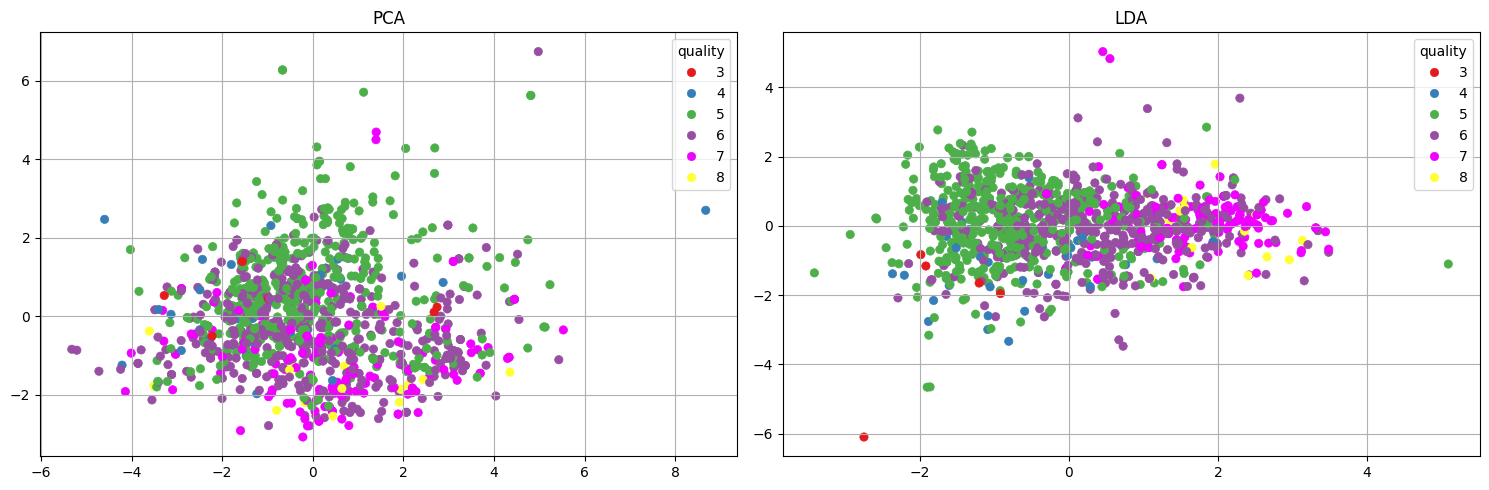

In [324]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# ===== WYKRESY =====
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PCA
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    edgecolor=None,
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("PCA")
axes[0].grid()

# LDA
sns.scatterplot(
    x=X_lda[:,0],
    y=X_lda[:,1],
    hue=y,
    edgecolor=None,
    palette=palette,
    ax=axes[1]
)
axes[1].set_title("LDA")
axes[1].grid()

plt.tight_layout()
plt.savefig("../charts/PCA_LDA.png")
plt.show()

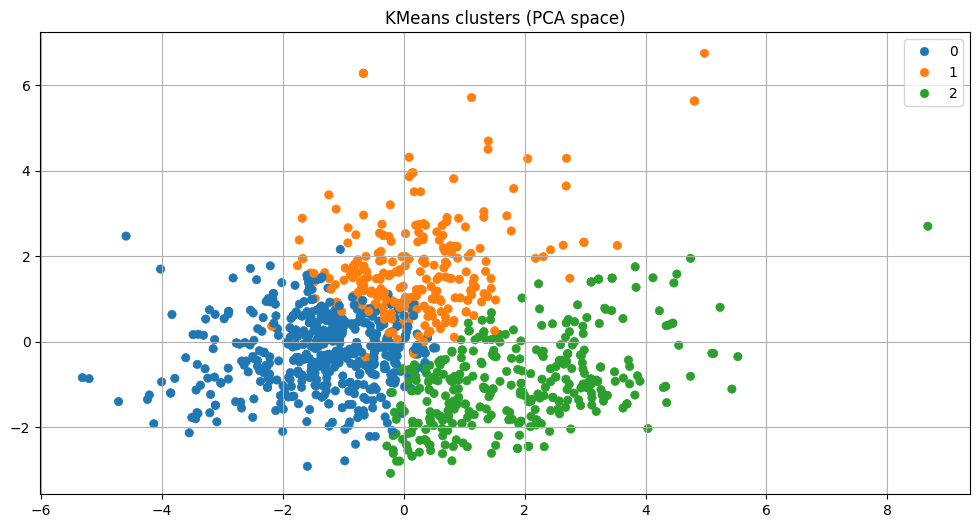

In [325]:
# KMeans (PCA space)
plt.figure(figsize=(12,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_pca.astype(str),
    edgecolor=None,
    palette="tab10",
)
plt.title("KMeans clusters (PCA space)")
plt.grid()
plt.savefig("../charts/k_mean.png")
plt.show()

## Obserwacje
- Wszystkie wartości zbioru są numeryczne, usunięto kolumnę Id
- Brak wartości pustych
- Brak duplikatów w zbiorze
- Widoczne jest duże niezbalansowanie zbioru
- Quality jest proporcjonalnie do cechy alcohol
- Quality jest odwrotnie proporcjonalnie do cechy volatile acidity
- Klasy jakości wina bardzo mocno się ze sobą mieszają i nie tworzą osobnych, wyraźnych grup
- KMeans jest bardzo wrażliwy na zmiany cech wejściowych

|  Klaster   |   Wszystkie cechy   | Po usunięciu cechy pH |
|:----------:|:-------------------:|:---------------------:|
|     0      |         523         |          336          |
|     1      |         271         |          500          |
|     2      |         349         |          307          |


## Wnioski
- Metoda redukcji wymiarów LDA (metoda nadzorowana) znacznie lepiej wizualizuje i separuje faktyczne klasy jakości w porównaniu do PCA (metody nienadzorowanej). Potwierdza to, że do skutecznego rozróżnienia profili win niezbędne jest jawne uwzględnienie etykiet klas w procesie modelowania, gdyż samo nienadzorowane podejście (KMeans/PCA) grupuje dane według ogólnego podobieństwa fizykochemicznego, a nie kryteriów jakościowych.
- Niezbędne jest zastosowanie metod wyrównujące balans między klasami np. SMOTE lub redukcja ilości klas
- Należy przeanalizować wartości odstające i zastosować odpowiednią metodę ich obsługi
- Algorytm KMeans na siłę podzielił dane na 3 równe klastry z prostymi granicami, natomiast można zauważyć, że poddział ten nie pokrywa się z prawdziwą jakością wina
- Gdy dla eksperymentu usunięto tylko jedną cechę (pH), cały podział natychmiast się rozsypał, a punkty zaczęły masowo przeskakiwać między klastrami (co widać w powyższej tabeli)

Po przeprowadzeniu eksperymentów z zadania klasyfikacji (w pliku main.py):
- Próba usunięcia 5% rekordów z najbardziej odstającymi wartościami, pogarsza wyniki klasyfikacji dla większości modeli. W ten sposób usuwane są również cechy wartościowe - usunięcie danych z tego zbioru nie jest wskazane (również ze względu na małą ilość obiektów)
- Ze względu na użycie modeli drzewiastych, które są odporne na wartości odstające, zdecydowano się na pozostawienie oryginalnego zbioru

In [4]:
from imblearn.over_sampling import SMOTE
import seaborn as sns

smote = SMOTE(k_neighbors=2, random_state=42)

X_smote, y_smote = smote.fit_resample(X_scaled, y)
X_smote_pca = pca.fit_transform(X_smote)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# przed SMOTE
sns.countplot(x=y, ax=axes[0])
axes[0].set_title("Set BEFORE Resampling")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].grid()

# po SMOTE
sns.countplot(x=y_smote, ax=axes[1])
axes[1].set_title("Set AFTER Resampling")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].grid()

plt.tight_layout()
plt.show()

NameError: name 'X_scaled' is not defined

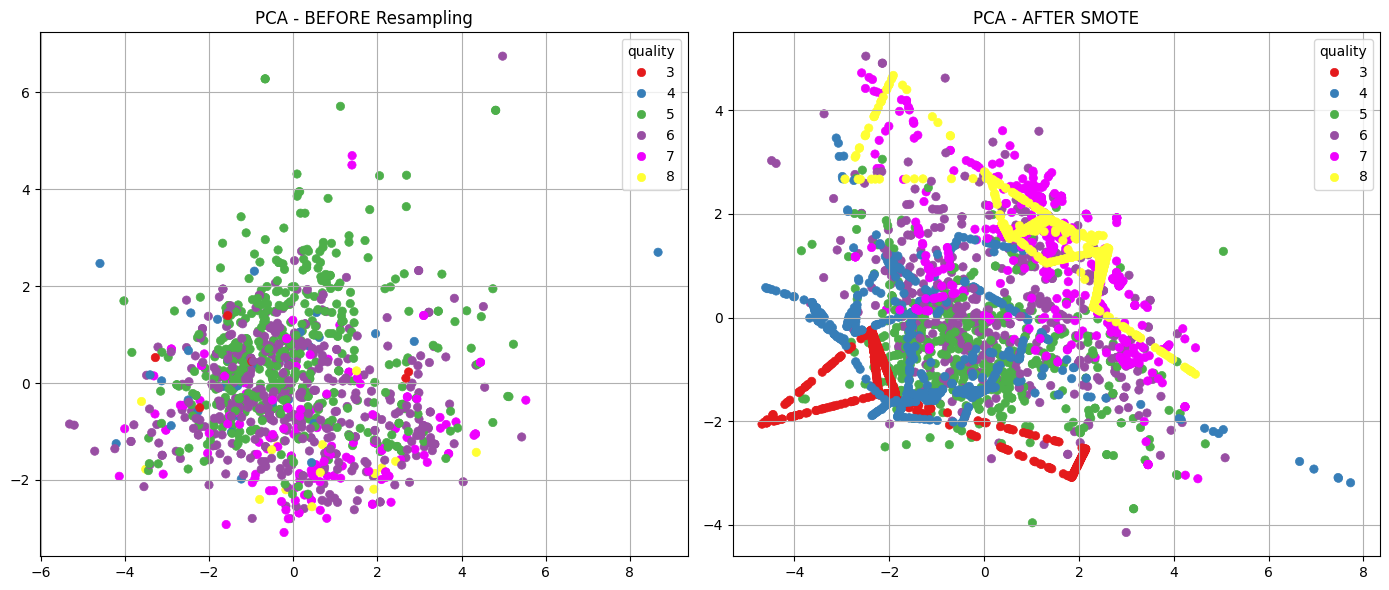

In [327]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BEFORE SMOTE
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,
    palette=palette,
    ax=axes[0],
    edgecolor=None
)
axes[0].set_title("PCA - BEFORE Resampling")
axes[0].grid()

# AFTER SMOTE
sns.scatterplot(
    x=X_smote_pca[:, 0],
    y=X_smote_pca[:, 1],
    hue=y_smote,
    palette=palette,
    ax=axes[1],
    edgecolor=None
)
axes[1].set_title("PCA - AFTER SMOTE")
axes[1].grid()

plt.tight_layout()
plt.savefig("../charts/smote.png")
plt.show()

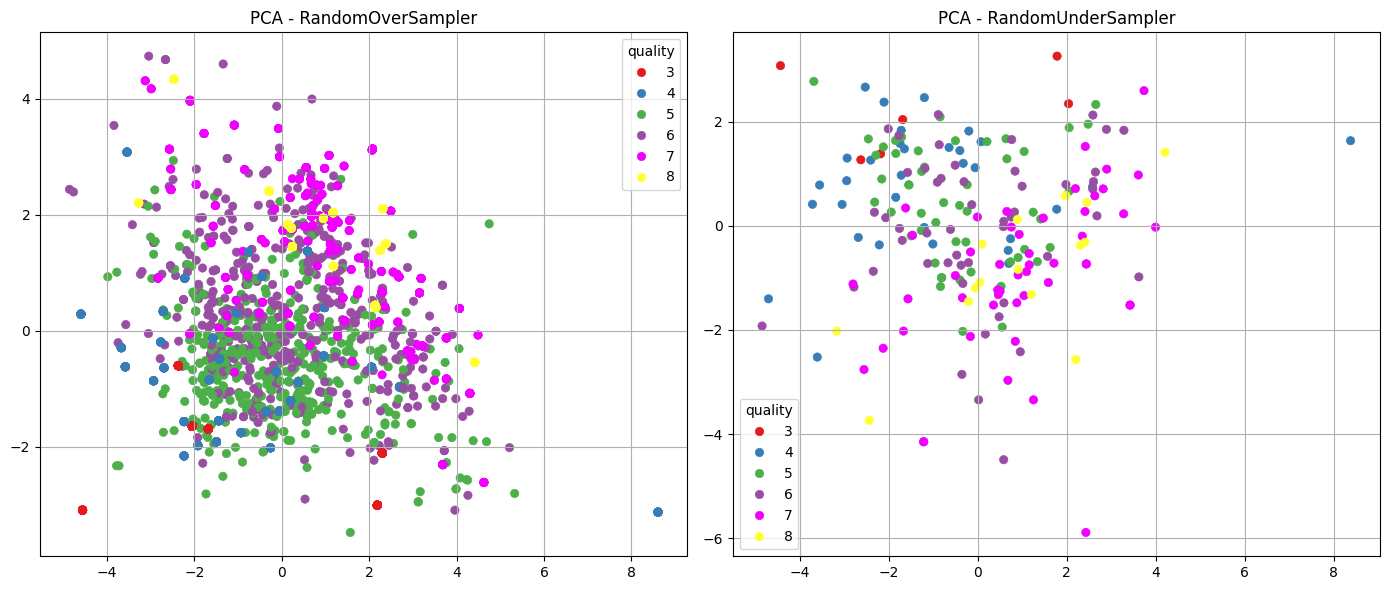

=== BEFORE Resampling ===
Samples: 1143
Unique samples: 1018
Duplicates: 125

=== AFTER ROS ===
Samples: 2898
Unique samples: 1018
Duplicates: 1880

=== AFTER RUS ===
Samples: 205
Unique samples: 200
Duplicates: 5


In [328]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# RANDOM OVERSAMPLING

ros = RandomOverSampler(
    #sampling_strategy={4: 159},
    random_state=42
)

X_ros, y_ros = ros.fit_resample(X_scaled, y)
X_ros_pca = pca.fit_transform(X_ros)

# UNDERSAMPLING

rus = RandomUnderSampler(
    sampling_strategy={5: 50, 6: 50, 7: 50},
    random_state=42
)

X_rus, y_rus = rus.fit_resample(X_scaled, y)
X_rus_pca = pca.fit_transform(X_rus)

# WYKRESY

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RANDOM OVERSAMPLING
sns.scatterplot(
    x=X_ros_pca[:, 0],
    y=X_ros_pca[:, 1],
    hue=y_ros,
    palette=palette,
    ax=axes[0],
    edgecolor=None
)
axes[0].set_title("PCA - RandomOverSampler")
axes[0].grid()

# UNDERSAMPLING
sns.scatterplot(
    x=X_rus_pca[:, 0],
    y=X_rus_pca[:, 1],
    hue=y_rus,
    palette=palette,
    ax=axes[1],
    edgecolor=None
)
axes[1].set_title("PCA - RandomUnderSampler")
axes[1].grid()

plt.tight_layout()
plt.savefig("../charts/ros_rus.png")
plt.show()

print("=== BEFORE Resampling ===")
print("Samples:", X_scaled.shape[0])

unique_before = np.unique(X_scaled, axis=0)
duplicates_before = X_scaled.shape[0] - unique_before.shape[0]

print("Unique samples:", unique_before.shape[0])
print("Duplicates:", duplicates_before)

print("\n=== AFTER ROS ===")
print("Samples:", X_ros.shape[0])

unique_after_ros = np.unique(X_ros, axis=0)
duplicates_after_ros = X_ros.shape[0] - unique_after_ros.shape[0]

print("Unique samples:", unique_after_ros.shape[0])
print("Duplicates:", duplicates_after_ros)

print("\n=== AFTER RUS ===")
print("Samples:", X_rus.shape[0])

unique_after_rus = np.unique(X_rus, axis=0)
duplicates_after_rus = X_rus.shape[0] - unique_after_rus.shape[0]

print("Unique samples:", unique_after_rus.shape[0])
print("Duplicates:", duplicates_after_rus)

### Wykresy dotyczące resamplingu mają na celu pokazać jak działają poszczególne metody
- Metody te powalają na określenie strategii, czyli wskazania które klasy należy resamplować do wyznaczonego poziomu
- Obecna stratgia oversamplingu to wyrównanie wszystkich klas do tej która zawiera najwięcej obiektów by pokazać ich działanie:
    - `Smote` - tworzy nowe obiekty między już istniejącymi obiektami
    - `RandomOverSampling` - losowo kopiuje istniejące obiekty
- Obecna strategia undersamplingu to redukcja klas 5,6,7 do poziomu 50 obiektów każda
    - `RandomUnderSampling` - losowo usuwa obiekty klas

(wykres po resamplingu ROS powinien być identyczny jak przed resamplingiem - jest on inny ze względu na późniejsze użycie PCA który otrzymał inny rozkład danych)

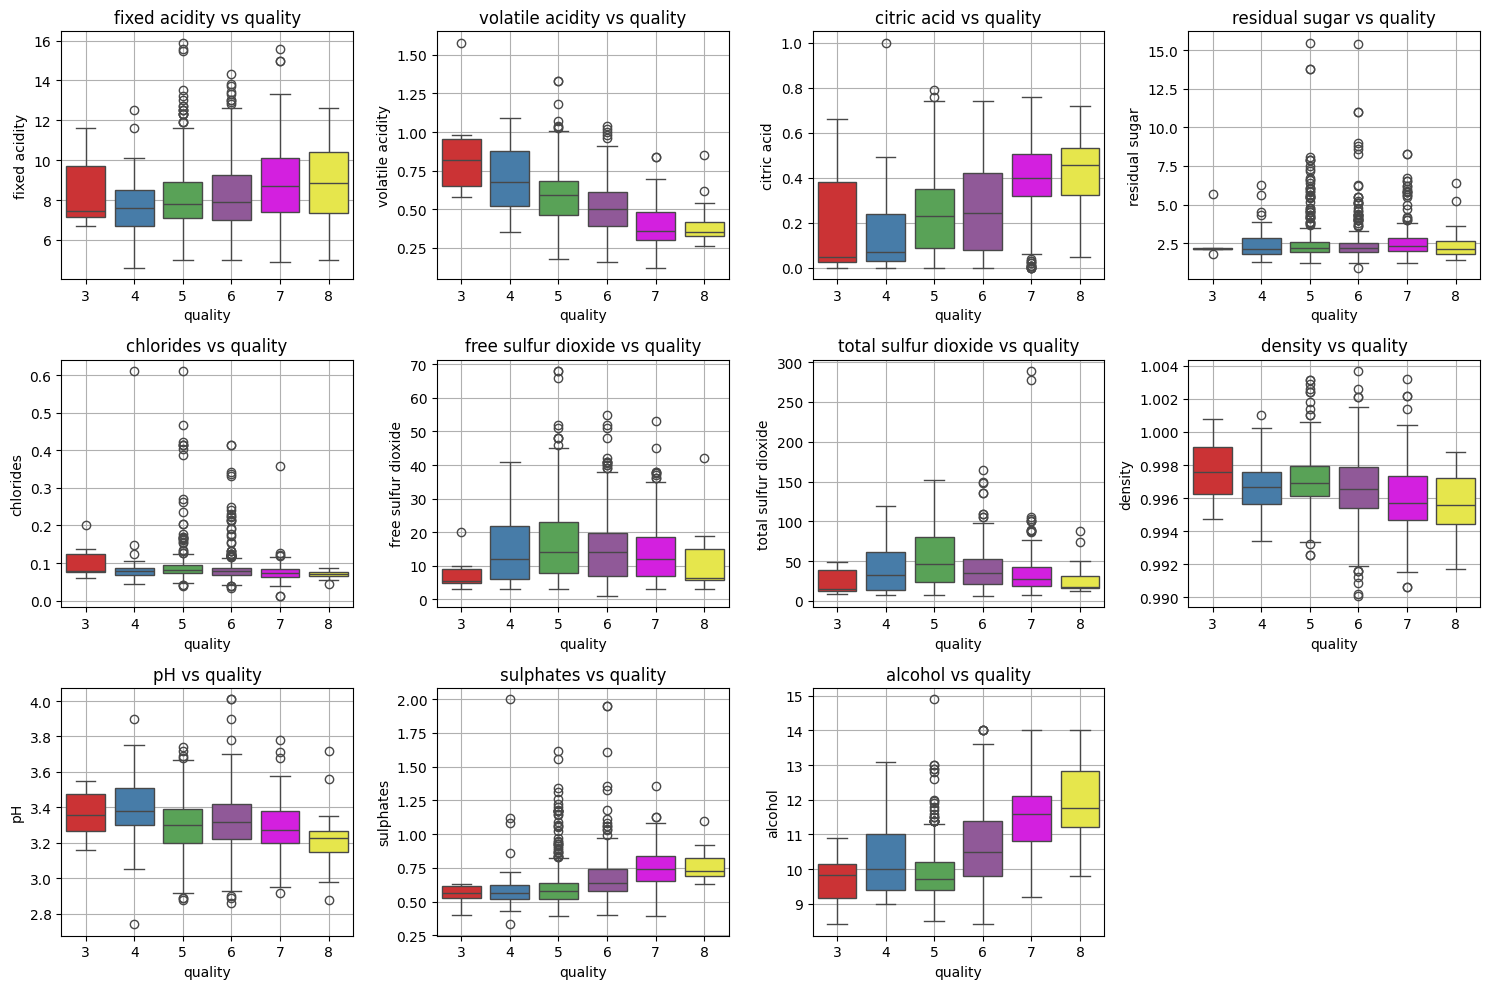

In [329]:
features = X.columns

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(3, 4, i+1)

    sns.boxplot(
        x=y,
        y=X[feature],
        hue=y,
        palette=palette,
        legend=False
    )

    plt.title(f"{feature} vs quality")
    plt.grid()

plt.tight_layout()
plt.show()

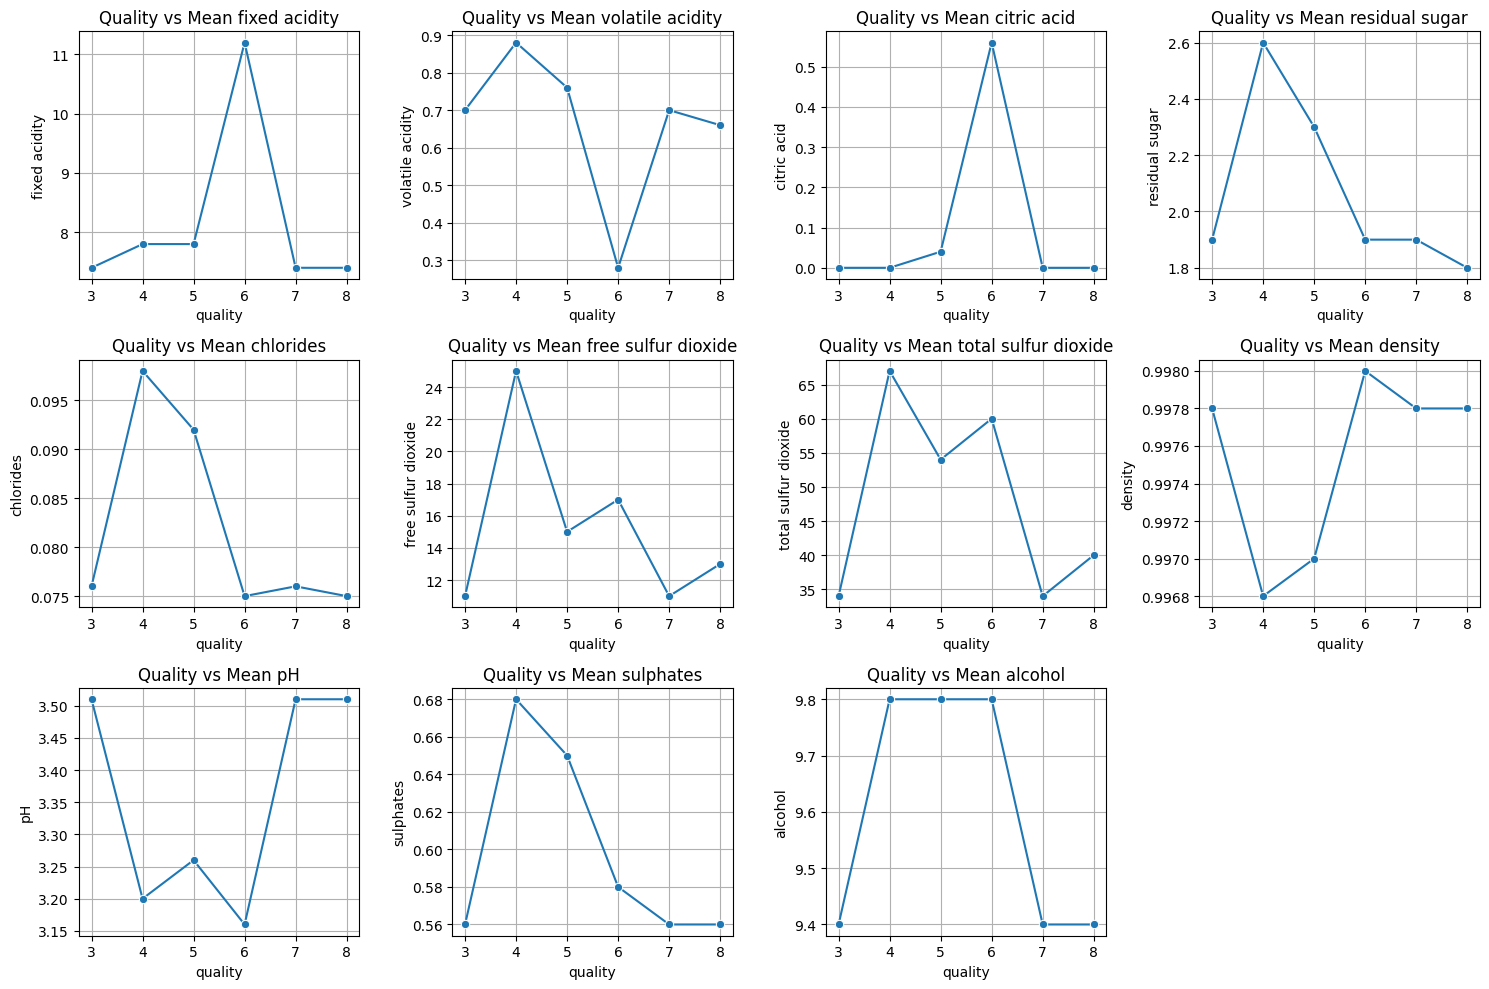

In [330]:
mean_values = df.groupby("quality").mean().reset_index()
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(3, 4, i+1)

    sns.lineplot(
        x="quality",
        y=X[feature],
        data=mean_values,
        marker="o"
    )
    plt.title(f"Quality vs Mean {feature}")
    plt.grid()


plt.tight_layout()
plt.show()